# Predicting Student Health Risk

## Baseline Model Development

This notebook develops three baseline classification models. The models are trained using the same training and validation datasets. Their performance is compared using balanced accuracy, normal accuracy, macro F1 score, classification reports, and confusion matrices.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_folder = current_folder
else:
    project_folder = current_folder.parent

data_folder = project_folder / "data" / "kaggle" / "raw"
models_folder = project_folder / "models"
results_folder = project_folder / "outputs" / "results"
figures_folder = project_folder / "outputs" / "figures"

models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Project folder")
print(project_folder)

Project folder
C:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project


In [3]:
train_file = data_folder / "train.csv"

preprocessor_file = models_folder / "preprocessing_pipeline.joblib"
column_file = models_folder / "column_information.joblib"

train_data = pd.read_csv(train_file)

column_information = joblib.load(column_file)

print("Training data loaded successfully")
print("Training data shape", train_data.shape)

Training data loaded successfully
Training data shape (690088, 15)


In [4]:
target_column = column_information["target_column"]
identifier_columns = column_information["identifier_columns"]

X = train_data.drop(columns=[target_column])
y = train_data[target_column]

if len(identifier_columns) > 0:
    X = X.drop(columns=identifier_columns)

print("Input feature shape", X.shape)
print("Target shape", y.shape)
print("Target classes")
print(y.unique())

Input feature shape (690088, 13)
Target shape (690088,)
Target classes
['unhealthy' 'at-risk' 'fit']


In [5]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training input shape", X_train.shape)
print("Validation input shape", X_validation.shape)

print()

print("Training class distribution")
print(y_train.value_counts(normalize=True).round(3))

print()

print("Validation class distribution")
print(y_validation.value_counts(normalize=True).round(3))

Training input shape (552070, 13)
Validation input shape (138018, 13)

Training class distribution
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64

Validation class distribution
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64


In [6]:
dummy_preprocessor = joblib.load(preprocessor_file)

dummy_model = Pipeline(
    steps=[
        (
            "preprocessor",
            dummy_preprocessor
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

dummy_model.fit(X_train, y_train)

print("Dummy Classifier trained successfully")

Dummy Classifier trained successfully


In [7]:
dummy_train_predictions = dummy_model.predict(X_train)
dummy_validation_predictions = dummy_model.predict(X_validation)

dummy_train_balanced_accuracy = balanced_accuracy_score(
    y_train,
    dummy_train_predictions
)

dummy_validation_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    dummy_validation_predictions
)

dummy_accuracy = accuracy_score(
    y_validation,
    dummy_validation_predictions
)

dummy_macro_f1 = f1_score(
    y_validation,
    dummy_validation_predictions,
    average="macro"
)

print("Dummy training balanced accuracy")
print(round(dummy_train_balanced_accuracy, 4))

print()

print("Dummy validation balanced accuracy")
print(round(dummy_validation_balanced_accuracy, 4))

print()

print("Dummy normal accuracy")
print(round(dummy_accuracy, 4))

print()

print("Dummy macro F1 score")
print(round(dummy_macro_f1, 4))

Dummy training balanced accuracy
0.3333

Dummy validation balanced accuracy
0.3333

Dummy normal accuracy
0.8587

Dummy macro F1 score
0.308


In [8]:
print(
    classification_report(
        y_validation,
        dummy_validation_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     at-risk       0.86      1.00      0.92    118512
         fit       0.00      0.00      0.00      7961
   unhealthy       0.00      0.00      0.00     11545

    accuracy                           0.86    138018
   macro avg       0.29      0.33      0.31    138018
weighted avg       0.74      0.86      0.79    138018



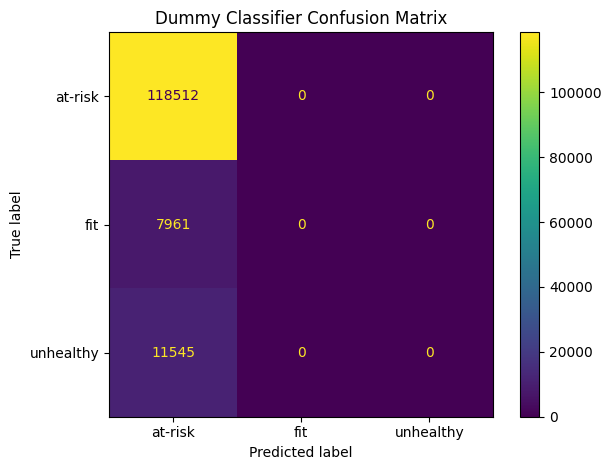

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    dummy_validation_predictions
)

plt.title("Dummy Classifier Confusion Matrix")
plt.tight_layout()

dummy_figure = figures_folder / "dummy_confusion_matrix.png"
plt.savefig(dummy_figure)

plt.show()

In [10]:
logistic_preprocessor = joblib.load(preprocessor_file)

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            logistic_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [11]:
logistic_train_predictions = logistic_model.predict(X_train)
logistic_validation_predictions = logistic_model.predict(X_validation)

logistic_train_balanced_accuracy = balanced_accuracy_score(
    y_train,
    logistic_train_predictions
)

logistic_validation_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    logistic_validation_predictions
)

logistic_accuracy = accuracy_score(
    y_validation,
    logistic_validation_predictions
)

logistic_macro_f1 = f1_score(
    y_validation,
    logistic_validation_predictions,
    average="macro"
)

print("Logistic training balanced accuracy")
print(round(logistic_train_balanced_accuracy, 4))

print()

print("Logistic validation balanced accuracy")
print(round(logistic_validation_balanced_accuracy, 4))

print()

print("Logistic normal accuracy")
print(round(logistic_accuracy, 4))

print()

print("Logistic macro F1 score")
print(round(logistic_macro_f1, 4))

Logistic training balanced accuracy
0.8566

Logistic validation balanced accuracy
0.8574

Logistic normal accuracy
0.798

Logistic macro F1 score
0.6577


In [12]:
print(
    classification_report(
        y_validation,
        logistic_validation_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     at-risk       0.98      0.78      0.87    118512
         fit       0.38      0.90      0.53      7961
   unhealthy       0.42      0.89      0.57     11545

    accuracy                           0.80    138018
   macro avg       0.59      0.86      0.66    138018
weighted avg       0.90      0.80      0.83    138018



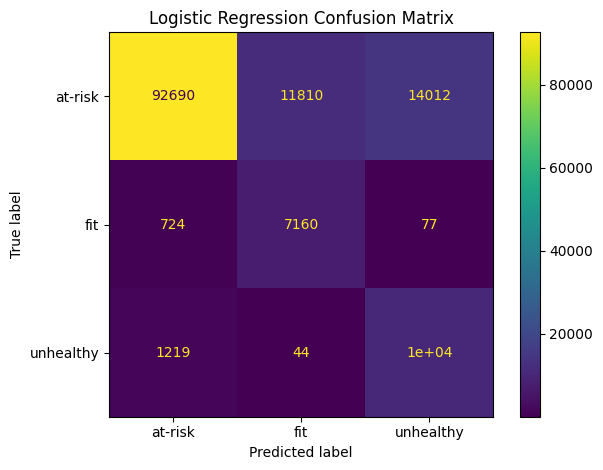

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_validation_predictions
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

logistic_figure = figures_folder / "logistic_confusion_matrix.png"
plt.savefig(logistic_figure)

plt.show()

In [14]:
tree_preprocessor = joblib.load(preprocessor_file)

decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [15]:
tree_train_predictions = decision_tree_model.predict(X_train)
tree_validation_predictions = decision_tree_model.predict(X_validation)

tree_train_balanced_accuracy = balanced_accuracy_score(
    y_train,
    tree_train_predictions
)

tree_validation_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    tree_validation_predictions
)

tree_accuracy = accuracy_score(
    y_validation,
    tree_validation_predictions
)

tree_macro_f1 = f1_score(
    y_validation,
    tree_validation_predictions,
    average="macro"
)

print("Decision Tree training balanced accuracy")
print(round(tree_train_balanced_accuracy, 4))

print()

print("Decision Tree validation balanced accuracy")
print(round(tree_validation_balanced_accuracy, 4))

print()

print("Decision Tree normal accuracy")
print(round(tree_accuracy, 4))

print()

print("Decision Tree macro F1 score")
print(round(tree_macro_f1, 4))

Decision Tree training balanced accuracy
0.8977

Decision Tree validation balanced accuracy
0.8974

Decision Tree normal accuracy
0.8289

Decision Tree macro F1 score
0.6995


In [16]:
print(
    classification_report(
        y_validation,
        tree_validation_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     at-risk       0.99      0.81      0.89    118512
         fit       0.42      0.92      0.58      7961
   unhealthy       0.47      0.96      0.63     11545

    accuracy                           0.83    138018
   macro avg       0.63      0.90      0.70    138018
weighted avg       0.91      0.83      0.85    138018



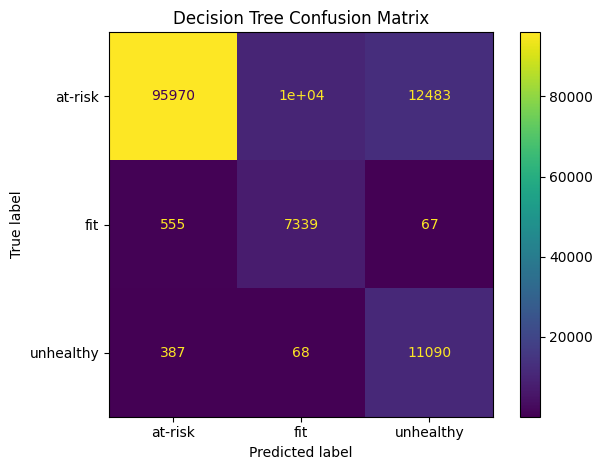

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    tree_validation_predictions
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()

tree_figure = figures_folder / "decision_tree_confusion_matrix.png"
plt.savefig(tree_figure)

plt.show()

In [18]:
model_names = [
    "Dummy Classifier",
    "Logistic Regression",
    "Decision Tree"
]

training_balanced_scores = [
    dummy_train_balanced_accuracy,
    logistic_train_balanced_accuracy,
    tree_train_balanced_accuracy
]

validation_balanced_scores = [
    dummy_validation_balanced_accuracy,
    logistic_validation_balanced_accuracy,
    tree_validation_balanced_accuracy
]

accuracy_scores = [
    dummy_accuracy,
    logistic_accuracy,
    tree_accuracy
]

macro_f1_scores = [
    dummy_macro_f1,
    logistic_macro_f1,
    tree_macro_f1
]

model_comparison = pd.DataFrame(
    {
        "Model": model_names,
        "Training Balanced Accuracy": training_balanced_scores,
        "Validation Balanced Accuracy": validation_balanced_scores,
        "Normal Accuracy": accuracy_scores,
        "Macro F1 Score": macro_f1_scores
    }
)

model_comparison = model_comparison.round(4)

model_comparison

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
0,Dummy Classifier,0.3333,0.3333,0.8587,0.3080
1,Logistic Regression,0.8566,0.8574,0.7980,0.6577
2,Decision Tree,0.8977,0.8974,0.8289,0.6995


In [19]:
model_comparison_sorted = model_comparison.sort_values(
    by="Validation Balanced Accuracy",
    ascending=False
)

model_comparison_sorted

,Model,Training Balanced Accuracy,Validation Balanced Accuracy,Normal Accuracy,Macro F1 Score
2,Decision Tree,0.8977,0.8974,0.8289,0.6995
1,Logistic Regression,0.8566,0.8574,0.7980,0.6577
0,Dummy Classifier,0.3333,0.3333,0.8587,0.3080


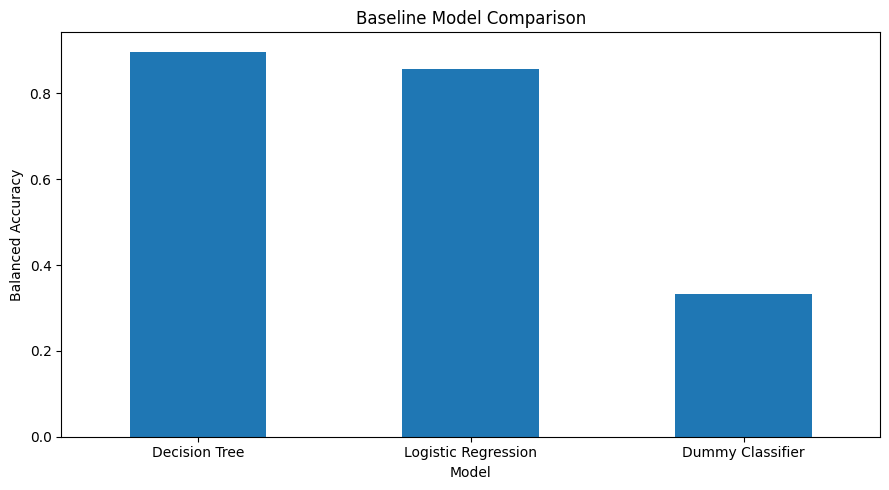

In [20]:
model_comparison_sorted.plot(
    x="Model",
    y="Validation Balanced Accuracy",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()

comparison_figure = figures_folder / "baseline_model_comparison.png"
plt.savefig(comparison_figure)

plt.show()

In [21]:
dummy_model_file = models_folder / "dummy_classifier.joblib"
logistic_model_file = models_folder / "logistic_regression.joblib"
tree_model_file = models_folder / "decision_tree.joblib"

joblib.dump(dummy_model, dummy_model_file)
joblib.dump(logistic_model, logistic_model_file)
joblib.dump(decision_tree_model, tree_model_file)

print("Baseline models saved successfully")

Baseline models saved successfully


In [22]:
comparison_file = results_folder / "baseline_model_comparison.csv"

model_comparison_sorted.to_csv(
    comparison_file,
    index=False
)

print("Model comparison saved successfully")
print(comparison_file)

Model comparison saved successfully
C:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\outputs\results\baseline_model_comparison.csv


In [23]:
print("Dummy model saved")
print(dummy_model_file.exists())

print()

print("Logistic Regression model saved")
print(logistic_model_file.exists())

print()

print("Decision Tree model saved")
print(tree_model_file.exists())

print()

print("Comparison file saved")
print(comparison_file.exists())

Dummy model saved
True

Logistic Regression model saved
True

Decision Tree model saved
True

Comparison file saved
True


## Baseline model findings

Three baseline models were developed and evaluated.

The Dummy Classifier achieved a validation balanced accuracy of 0.3333.

Logistic Regression achieved a validation balanced accuracy of 0.8574.

The Decision Tree achieved the highest baseline balanced accuracy of 0.8974.

The Decision Tree training balanced accuracy was 0.8977, giving a small gap of 0.0003. This shows that the model performed consistently without clear overfitting.

The Dummy Classifier achieved a normal accuracy of 0.8587 because it predicted the majority class, but it failed to identify the smaller classes.

Balanced accuracy was used as the main measurement because the target classes are imbalanced.

The next stage is the development of stronger tree-based models.